# Customer Churn — Exploratory Data Analysis

## Objective

The objective of this stage is to explore the cleaned customer dataset and identify patterns, distributions, relationships, and customer segments associated with churn.

The analysis will focus on answering business-driven questions rather than creating visualizations without a specific analytical purpose.

## EDA Approach

The analysis will follow the framework:

Business Question → Analysis → Visualization → Finding → Business Meaning

The major areas of investigation include:

1. Overall churn distribution
2. Customer demographics
3. Tenure and customer lifecycle
4. Services and subscription characteristics
5. Contract and payment behavior
6. Monthly and total charges
7. Relationships between customer characteristics and churn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    "../data/processed/customer_churn_cleaned.csv"
)

df.head()

,CustomerID,Gender,Age,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,C06889,Male,54.0,0,No,No,37,Yes,No,Fiber optic,...,No,No,Yes,No,Two year,No,Bank transfer,67.75,2661.460,No
1,C00415,Female,46.0,0,Yes,No,16,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,52.25,978.530,No
2,C03600,Female,34.0,0,No,No,0,Yes,No,DSL,...,No,Yes,No,No,One year,No,Electronic check,53.07,41.960,No
3,C01028,Female,52.0,0,No,No,23,Yes,Yes,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Bank transfer,71.13,1437.955,No
4,C04489,Female,29.0,0,No,No,16,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,33.48,597.840,No


# Verify Before EDA, sanity check

"Before I analyze this dataset, let me make sure I'm analyzing the cleaned version I expect."

In [ ]:
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (7250, 22)
Missing values: 0
Duplicate rows: 0


# EDA Question 1 — What Is the Overall Churn Distribution?

In [4]:
df["Churn"].value_counts()

Churn
No     5411
Yes    1839
Name: count, dtype: int64

# Calculate Churn Percentage

In [5]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     74.634483
Yes    25.365517
Name: proportion, dtype: float64

In [6]:
# Churn Rate

churn_rate = (
    (df["Churn"] == "Yes").mean() * 100
)

print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 25.37%


# First Visualization

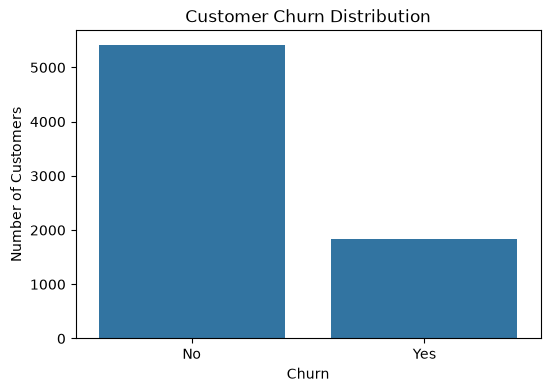

In [7]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

`Finding`

Approximately 25% of customers have churned, while approximately 75% have remained.

`Business meaning`

This indicates that customer churn is a significant business issue and warrants investigation into the characteristics of customers who leave.

# Does SeniorCitizen status have a relationship with churn?

In [8]:
df.groupby("SeniorCitizen")["Churn"].value_counts()

SeniorCitizen  Churn
0              No       5049
               Yes      1711
1              No        362
               Yes       128
Name: count, dtype: int64

In [9]:
churn_by_senior = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_senior

Churn,No,Yes
SeniorCitizen,,
0,74.689349,25.310651
1,73.877551,26.122449


`What does this tell the business?`

Senior customers have a slightly higher observed churn rate than non-senior customers (26.12% vs. 25.31%), but the difference is small at approximately 0.81 percentage points.

SeniorCitizen status does not appear to be a strong standalone differentiator of churn in this dataset.

In [10]:
# Visualize churn rate by senior citizen status

churn_by_senior = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn_rate = churn_by_senior["Yes"]

senior_churn_rate

SeniorCitizen
0    25.310651
1    26.122449
Name: Yes, dtype: float64

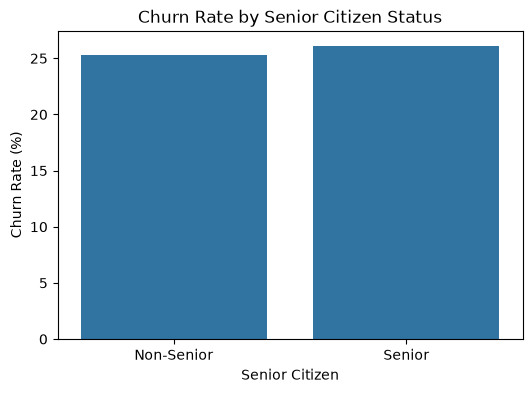

In [14]:
plt.figure(figsize=(6, 4))

senior_churn_rate.index = [
    "Non-Senior",
    "Senior"
]

sns.barplot(
    x=senior_churn_rate.index,
    y=senior_churn_rate.values
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

plt.show()

`Finding`

The churn rate is 25.31% among non-senior customers and 26.12% among senior customers. The difference is only 0.81 percentage points, indicating that senior citizen status alone does not show a strong difference in churn in this dataset.

`Business Meaning`

Senior citizen status does not appear to be a major standalone churn differentiator. Therefore, retention analysis should investigate other customer characteristics such as contract type, tenure, services, payment method, and charges.

# "What did you find about senior citizens and churn?"

A strong answer:

"I compared churn rates within senior and non-senior customer groups rather than comparing raw churn counts. Non-senior customers had a churn rate of 25.31%, while senior customers had a churn rate of 26.12%. The difference was only 0.81 percentage points, so I would not consider SeniorCitizen status a strong churn differentiator based on this analysis alone. I would investigate other variables before making a retention recommendation."

# Next Analysis

Does having a `partner` relate to customer churn?

In [ ]:
pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index" # Calculate percentages within each Partner category.
) * 100

Churn,No,Yes
Partner,,
No,73.323580,26.676420
Yes,76.341696,23.658304


`Finding`

Customers without a partner have a higher observed churn rate (26.68%) compared with customers who have a partner (23.66%), a difference of approximately 3.02 percentage points.

Notice the wording "observed churn rate". We don't say that having a partner causes lower churn.

`Business meaning`

A possible interpretation is that customers without a partner may have somewhat higher churn risk, but Partner alone is not enough to explain why customers leave.

Partner status shows a moderate difference in observed churn rates. Customers without a partner may represent a segment worth examining further, but Partner status alone does not establish the reason for churn. Additional factors such as tenure, contract type, and service usage should be analyzed to determine whether this pattern persists across different customer segments.

# Next Analysis

Does having a `dependents` relate to customer churn?

In [16]:
pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Dependents,,
No,74.025974,25.974026
Yes,76.734193,23.265807


`Finding`

Customers without dependents have a higher observed churn rate (25.97%) compared with customers with dependents (23.27%), representing a difference of approximately 2.71 percentage points.

`Business Meaning`

Customers with dependents show a somewhat lower observed churn rate. This may indicate greater customer stability among households with dependents, although the relationship does not establish causation. Further analysis of tenure, contract type, services, and charges is required before using dependents as a basis for retention strategies.

# Next Analysis

Does having a `tenure` relate to customer churn?

In [17]:
df["Tenure"].describe()

count    7250.000000
mean       28.909241
std        19.119493
min         0.000000
25%        14.000000
50%        28.000000
75%        43.000000
max        72.000000
Name: Tenure, dtype: float64

In [18]:
df["Tenure"].value_counts().sort_index()

Tenure
0     634
1      77
2      75
3      58
4      72
     ... 
68     25
69     14
70     15
71     16
72    132
Name: count, Length: 73, dtype: int64

In [19]:
# Does churn actually vary with tenure?

tenure_churn = (
    pd.crosstab(
        df["Tenure"],
        df["Churn"],
        normalize="index"
    ) * 100
)

tenure_churn.head(15)

Churn,No,Yes
Tenure,,
0,49.684543,50.315457
1,61.038961,38.961039
2,57.333333,42.666667
3,67.241379,32.758621
4,55.555556,44.444444
5,42.708333,57.291667
6,64.383562,35.616438
7,58.666667,41.333333
8,57.843137,42.156863


In [20]:
tenure_churn["Yes"].head(15)

Tenure
0     50.315457
1     38.961039
2     42.666667
3     32.758621
4     44.444444
5     57.291667
6     35.616438
7     41.333333
8     42.156863
9     37.078652
10    34.736842
11    44.954128
12    34.000000
13    39.823009
14    32.539683
Name: Yes, dtype: float64

let's choose the groups carefully

0–6: first six months → onboarding/initial experience
7–12: remainder of first year
13–24: second year
25–48: established customers
49–72: long-term customers

In [5]:
tenure_bins = [0, 6, 12, 24, 48, 72]

tenure_labels = [
    "0–6 months",
    "7–12 months",
    "13–24 months",
    "25–48 months",
    "49–72 months"
]

df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

In [25]:
df[["Tenure", "TenureGroup"]].head(20)

,Tenure,TenureGroup
0,37,25–48 months
1,16,13–24 months
2,0,0–6 months
3,23,13–24 months
4,16,13–24 months
5,12,7–12 months
6,43,25–48 months
7,44,25–48 months
8,29,25–48 months
9,33,25–48 months


In [23]:
df["TenureGroup"].value_counts().sort_index()

TenureGroup
0–6 months      1085
7–12 months      570
13–24 months    1510
25–48 months    2830
49–72 months    1255
Name: count, dtype: int64

In [27]:
# Which customer lifecycle stage has the highest churn rate?

tenure_group_churn = (
    pd.crosstab(
        df["TenureGroup"],
        df["Churn"],
        normalize="index"
    ) * 100
)

tenure_group_churn

Churn,No,Yes
TenureGroup,,
0–6 months,52.718894,47.281106
7–12 months,60.877193,39.122807
13–24 months,67.880795,32.119205
25–48 months,81.519435,18.480565
49–72 months,92.430279,7.569721


Customer lifecycle appears to be much more strongly associated with churn than the demographic variables we've examined so far.

`Finding`

Churn decreases consistently as customer tenure increases. Customers with 0–6 months of tenure have the highest observed churn rate at 47.28%, while customers with 49–72 months have the lowest at 7.57%.

`Business meaning`

The highest churn risk appears to occur during the early customer lifecycle. This suggests that customer acquisition may not be the only challenge; retaining customers during their first several months could be particularly important. The company should investigate onboarding experience, early service issues, contract type, pricing, and payment behavior among newer customers.

# Let's visualize this pattern

Because TenureGroup represents an ordered lifecycle, a bar chart is appropriate for comparing the churn rate of these discrete business buckets.

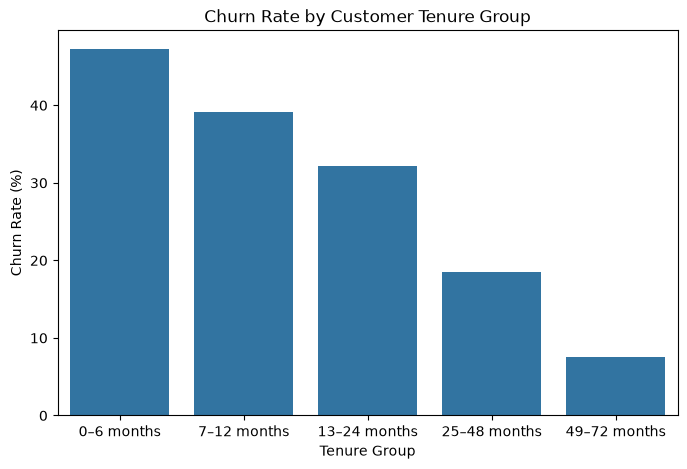

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=tenure_group_churn.index,
    y=tenure_group_churn["Yes"].values
)

plt.title("Churn Rate by Customer Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.show()

# "What is your strongest EDA finding so far?"

You could say:

"The strongest pattern I observed was the relationship between customer tenure and churn. Churn was highest among customers with 0–6 months of tenure at 47.28% and decreased consistently across each subsequent tenure group, reaching 7.57% among customers with 49–72 months of tenure. This indicates that the early customer lifecycle may be a critical period for retention. However, since EDA identifies associations rather than causation, I would further investigate contract type, services, charges, and payment behavior to understand what may be driving this pattern."

# What characteristics of the customer's subscription might be associated with churn?

In [29]:
contract_churn = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,61.443351,38.556649
One year,88.535032,11.464968
Two year,92.756410,7.243590


`Finding`

Contract type shows a strong association with customer churn. Month-to-month customers have the highest observed churn rate at 38.56%, compared with 11.46% for one-year contracts and 7.24% for two-year contracts.

`Business Meaning`

Customers with month-to-month contracts appear considerably more likely to churn than customers with longer-term contracts. This may reflect lower customer commitment or differences in the customer segments choosing each contract type. Contract type should therefore be investigated further alongside tenure, pricing, and service characteristics before developing retention strategies.

# Are newer customers more likely to have month-to-month contracts?

In [30]:
pd.crosstab(
    df["TenureGroup"],
    df["Contract"],
    normalize="index"
) * 100

Contract,Month-to-month,One year,Two year
TenureGroup,,,
0–6 months,88.940092,8.663594,2.396313
7–12 months,81.578947,11.754386,6.666667
13–24 months,71.125828,19.668874,9.205298
25–48 months,44.381625,31.625442,23.992933
49–72 months,16.175299,29.800797,54.023904


`Within each customer lifecycle stage, how does contract type relate to churn?`

In [31]:
contract_tenure_churn = (
    df.groupby(
        ["TenureGroup", "Contract"]
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .unstack()
)

contract_tenure_churn

Contract,Month-to-month,One year,Two year
TenureGroup,,,
0–6 months,50.259067,22.340426,26.923077
7–12 months,44.301075,17.910448,13.157895
13–24 months,38.733706,14.141414,19.424460
25–48 months,30.812102,9.720670,7.216495
49–72 months,16.748768,9.625668,3.687316


Month-to-month customers have a much higher churn rate.

This gives us a more specific segment: New + Month-to-month rather than simply: New customers

# "What did you discover during EDA?"

You could say:

"Tenure and contract type both showed strong associations with churn. Overall, churn decreased as customer tenure increased, from 47.28% among customers with 0–6 months of tenure to 7.57% among customers with 49–72 months. Contract type showed a similar pattern, with month-to-month customers having substantially higher churn. I then segmented the analysis by tenure and found that month-to-month customers had the highest churn rate within every tenure group. This suggested that early-tenure, month-to-month customers could be an important high-risk segment for further investigation."

`Finding`

Contract type and tenure both show strong associations with customer churn. Month-to-month customers have the highest churn rate within every tenure group. The highest observed churn rate occurs among customers with 0–6 months of tenure and a month-to-month contract (50.26%), while the lowest occurs among customers with 49–72 months of tenure and a two-year contract (3.69%).

`Business Meaning`

The combination of early tenure and month-to-month contracts represents a potentially high-risk customer segment. This suggests that retention efforts may need to focus particularly on customers during the early lifecycle, especially those without long-term contracts. Further analysis of service usage, charges, and payment behavior can help identify the underlying factors associated with this segment's higher churn.

# Next Analysis

Does the customer's payment method relate to churn?

In [4]:
payment_churn = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    ) * 100
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer,80.310263,19.689737
Credit card,80.193548,19.806452
Electronic check,66.902655,33.097345
Mailed check,77.731443,22.268557


Electronic check is very different from the others.

Electronic check → 33.10%
Mailed check → 22.27%
Credit card → 19.81%
Bank transfer → 19.69%

Customers using electronic checks have the highest observed churn rate at 33.10%, compared with 19.69% for bank transfers, 19.81% for credit cards, and 22.27% for mailed checks.

`Is the high churn among electronic-check customers still present across different contract types?`

In [5]:
payment_contract_churn = (
    df.groupby(
        ["Contract", "PaymentMethod"]
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .unstack()
)

payment_contract_churn

PaymentMethod,Bank transfer,Credit card,Electronic check,Mailed check
Contract,,,,
Month-to-month,30.546265,30.759651,46.721796,37.894737
One year,8.905852,8.759124,15.959253,9.880240
Two year,5.440415,7.142857,9.208103,6.101695


The combination of month-to-month contract and electronic check is associated with substantially higher observed churn, making this segment worth further investigation.

In [8]:
tenure_payment_churn = (
    df.groupby(
        ["TenureGroup", "PaymentMethod"]
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .unstack()
)

tenure_payment_churn

PaymentMethod,Bank transfer,Credit card,Electronic check,Mailed check
TenureGroup,,,,
0–6 months,41.422594,39.301310,53.930131,48.427673
7–12 months,30.985915,34.645669,50.724638,31.914894
13–24 months,23.652695,21.518987,41.920000,32.340426
25–48 months,12.996942,14.237856,25.461255,15.555556
49–72 months,7.491857,7.117438,9.977827,3.240741


# TenureGroup + Contract + PaymentMethod + Churn

In [9]:
high_risk_segment = (
    df.groupby(
        ["TenureGroup", "Contract", "PaymentMethod"]
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

high_risk_segment

TenureGroup   Contract        PaymentMethod   
0–6 months    Month-to-month  Bank transfer       43.778802
                              Credit card         41.884817
                              Electronic check    56.190476
                              Mailed check        54.014599
              One year        Bank transfer       23.529412
                              Credit card         23.333333
                              Electronic check    30.000000
                              Mailed check         5.882353
              Two year        Bank transfer        0.000000
                              Credit card         37.500000
                              Electronic check    25.000000
                              Mailed check        40.000000
7–12 months   Month-to-month  Bank transfer       35.344828
                              Credit card         38.947368
                              Electronic check    54.748603
                              Mailed check        40.

The percentages look dramatically different, but the underlying groups are tiny.

That's why churn rate alone isn't enough when doing detailed segmentation.

# Let's check the customer counts

In [10]:
segment_counts = (
    df.groupby(
        ["TenureGroup", "Contract", "PaymentMethod"]
    )
    .size()
)

segment_counts

TenureGroup   Contract        PaymentMethod   
0–6 months    Month-to-month  Bank transfer       217
                              Credit card         191
                              Electronic check    420
                              Mailed check        137
              One year        Bank transfer        17
                              Credit card          30
                              Electronic check     30
                              Mailed check         17
              Two year        Bank transfer         5
                              Credit card           8
                              Electronic check      8
                              Mailed check          5
7–12 months   Month-to-month  Bank transfer       116
                              Credit card          95
                              Electronic check    179
                              Mailed check         75
              One year        Bank transfer        19
                              Credi

Overall churn
    ↓
25.37%
    ↓
Tenure is strongly associated with churn
    ↓
Early customers have higher churn
    ↓
Contract is also strongly associated with churn
    ↓
Month-to-month customers have higher churn
    ↓
Payment method is also associated with churn
    ↓
Electronic check has higher churn
    ↓
The payment-method pattern remains within
tenure and contract segments
    ↓
High-risk segment identified:
0–6 months + Month-to-month + Electronic check
    ↓
56.19% churn among 420 customers

# Does the type of internet service relate to customer churn?

In [11]:
internet_churn = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    ) * 100
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,77.903683,22.096317
Fiber optic,65.449842,34.550158
No,93.000000,7.000000


Fiber optic customers have the highest observed churn rate at 34.55%, compared with 22.10% for DSL customers and 7.00% for customers without internet service. This suggests that internet-service type is associated with customer churn, with Fiber optic customers representing a higher-risk segment.

`Does the relationship between InternetService and churn remain when we account for customer tenure?`

In [12]:
internet_tenure_churn = (
    df.groupby(
        ["TenureGroup", "InternetService"]
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .unstack()
)

internet_tenure_churn

InternetService,DSL,Fiber optic,No
TenureGroup,,,
0–6 months,41.081081,62.873134,13.407821
7–12 months,34.500000,51.957295,8.988764
13–24 months,29.208925,42.112299,9.665428
25–48 months,16.479017,25.130890,5.038760
49–72 months,4.640371,11.785095,2.834008


Pattern 1 — Churn decreases as tenure increases
Pattern 2 — Fiber optic has the highest churn within every tenure group

Internet service type is associated with customer churn across all tenure groups. Fiber optic customers consistently show the highest observed churn rate within each tenure segment, reaching 62.87% among customers with 0–6 months of tenure. Churn declines with increasing tenure across all three internet-service categories.

# Does Fiber optic still have higher churn when comparing customers with the same contract type?

In [13]:
internet_contract_churn = (
    df.groupby(
        ["Contract", "InternetService"]
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .unstack()
)

internet_contract_churn

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,33.013294,52.106084,11.516035
One year,11.531842,15.365854,1.533742
Two year,5.970149,10.054348,2.430556


Pattern A — Contract type matters
Pattern B — Fiber optic remains the highest within each contract group

Fiber optic customers consistently show higher observed churn than DSL and customers without internet service, even when comparing customers within the same contract type.

Fiber optic service is associated with higher observed churn in this dataset, and the pattern remains visible across contract types.

# Are customers who do not have services such as OnlineSecurity or TechSupport more likely to churn?

In [14]:
techsupport_churn = (
    pd.crosstab(
        df["TechSupport"],
        df["Churn"],
        normalize="index"
    ) * 100
)

techsupport_churn

Churn,No,Yes
TechSupport,,
No,68.942568,31.057432
No internet service,93.000000,7.000000
Yes,74.220814,25.779186


In [15]:
internet_customers = df[
    df["InternetService"] != "No"
]

techsupport_internet_churn = (
    pd.crosstab(
        internet_customers["TechSupport"],
        internet_customers["Churn"],
        normalize="index"
    ) * 100
)

techsupport_internet_churn

Churn,No,Yes
TechSupport,,
No,68.942568,31.057432
Yes,74.220814,25.779186


Among customers with internet service, those without TechSupport have a higher observed churn rate (31.06%) than customers with TechSupport (25.78%), a difference of approximately 5.28 percentage points.

In [16]:
techsupport_internet_churn = (
    df[df["InternetService"] != "No"]
    .groupby(
        ["InternetService", "TechSupport"]
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .unstack()
)

techsupport_internet_churn

TechSupport,No,Yes
InternetService,,
DSL,23.685765,18.637532
Fiber optic,36.336717,30.762332


Pattern A — TechSupport is associated with lower churn within both internet types.

Pattern B — Fiber optic remains higher in both TechSupport groups   

Among customers with internet service, those without TechSupport show higher observed churn than those with TechSupport within both DSL and Fiber optic segments. The difference is approximately 5.05 percentage points for DSL and 5.57 percentage points for Fiber optic. However, Fiber optic customers continue to show higher churn regardless of TechSupport status, indicating that other factors may also contribute to the higher churn observed among Fiber optic customers.

`Churn rate + customer count.`

In [17]:
techsupport_internet_counts = (
    df[df["InternetService"] != "No"]
    .groupby(
        ["InternetService", "TechSupport"]
    )
    .size()
)

techsupport_internet_counts

InternetService  TechSupport
DSL              No             1693
                 Yes             778
Fiber optic      No             2364
                 Yes            1115
dtype: int64

`Final finding`

Among customers with internet service, customers without TechSupport have higher observed churn than those with TechSupport. This pattern persists across both DSL and Fiber optic customers, with churn differences of approximately 5 percentage points within each service type. Fiber optic customers without TechSupport form a sizable higher-churn segment, with 2,364 customers and a 36.34% observed churn rate.

`Business meaning`

This suggests that TechSupport availability may be relevant to retention, particularly among Fiber optic customers. The company could investigate whether support accessibility, service issues, or customer experience contribute to the higher churn observed among customers without TechSupport.

# Do customers with higher monthly charges have higher observed churn?

In [19]:
df["MonthlyChargesGroup"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

In [20]:
df["MonthlyChargesGroup"].value_counts().sort_index()

MonthlyChargesGroup
Low            1813
Medium-Low     1812
Medium-High    1812
High           1813
Name: count, dtype: int64

In [21]:
df.groupby("MonthlyChargesGroup", observed=True)["MonthlyCharges"].agg(
    ["min", "median", "max", "count"]
)

,min,median,max,count
MonthlyChargesGroup,,,,
Low,18.00,30.880,45.93,1813
Medium-Low,45.94,54.180,59.79,1812
Medium-High,59.81,64.715,69.80,1812
High,69.82,76.550,101.20,1813


In [22]:
monthly_charges_churn = (
    pd.crosstab(
        df["MonthlyChargesGroup"],
        df["Churn"],
        normalize="index"
    ) * 100
)

monthly_charges_churn

Churn,No,Yes
MonthlyChargesGroup,,
Low,88.692774,11.307226
Medium-Low,75.772627,24.227373
Medium-High,69.757174,30.242826
High,64.313293,35.686707


# Calculate the Churn Rate

In [23]:
monthly_charge_contract_churn = (
    df.groupby(
        ["MonthlyChargesGroup", "Contract"]
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .unstack()
)

monthly_charge_contract_churn

Contract,Month-to-month,One year,Two year
MonthlyChargesGroup,,,
Low,17.882837,4.044944,3.291139
Medium-Low,36.036036,13.033175,6.138107
Medium-High,45.654346,13.986014,8.115183
High,54.242424,15.081206,11.479592


Pattern A — Within every contract type, churn increases with MonthlyCharges

Pattern B — Contract type has an even stronger difference


MonthlyCharges and Contract type both show strong associations with customer churn. Within each contract type, churn generally increases as MonthlyCharges increase. However, contract type shows a much larger difference in observed churn rates, with month-to-month customers consistently having higher churn than one-year and two-year customers across all MonthlyCharges groups. The highest observed churn rate is 54.24% among customers with high MonthlyCharges and month-to-month contracts.

High-charge month-to-month customers represent a potentially high-risk segment. The company could investigate whether pricing, perceived value, service usage, or customer expectations contribute to the higher churn observed in this segment.

In [24]:
# This tells us how many customers are in each combination.

monthly_charge_contract_counts = (
    df.groupby(
        ["MonthlyChargesGroup", "Contract"]
    ).size()
    .unstack()
)

monthly_charge_contract_counts

Contract,Month-to-month,One year,Two year
MonthlyChargesGroup,,,
Low,973,445,395
Medium-Low,999,422,391
Medium-High,1001,429,382
High,990,431,392


# Final MonthlyCharges finding

MonthlyCharges showed a strong positive association with churn. Overall churn increased from 11.31% among customers in the Low monthly-charge group to 35.69% among customers in the High group. This pattern remained within each contract type, with month-to-month customers showing the strongest increase, from 17.88% churn in the Low-charge group to 54.24% in the High-charge group. The High-charge, month-to-month segment contains 990 customers, making it a sizable high-risk segment.

Business meaning

High-charge customers, particularly those on month-to-month contracts, represent a potentially important retention segment. The company could investigate whether pricing, perceived value, service characteristics, or customer expectations contribute to the higher churn observed in this group.

# Do customers with higher accumulated TotalCharges show different churn rates?

In [25]:
df["TotalChargesGroup"] = pd.qcut(
    df["TotalCharges"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

In [26]:
df["TotalChargesGroup"].value_counts().sort_index()

TotalChargesGroup
Low            1813
Medium-Low     1812
Medium-High    1812
High           1813
Name: count, dtype: int64

In [27]:
total_charges_groups = (
    df.groupby("TotalChargesGroup", observed=True)["TotalCharges"]
      .agg(["min", "median", "max", "count"])
)

total_charges_groups

,min,median,max,count
TotalChargesGroup,,,,
Low,0.35,285.360,743.21,1813
Medium-Low,744.88,1126.855,1506.04,1812
Medium-High,1509.34,1927.710,2486.07,1812
High,2486.55,3251.130,7084.30,1813


In [28]:
total_charges_churn = (
    pd.crosstab(
        df["TotalChargesGroup"],
        df["Churn"],
        normalize="index"
    ) * 100
)

total_charges_churn

Churn,No,Yes
TotalChargesGroup,,
Low,61.831219,38.168781
Medium-Low,73.454746,26.545254
Medium-High,77.373068,22.626932
High,85.879757,14.120243


"TotalCharges is strongly correlated with Tenure, so lower TotalCharges may partly reflect shorter customer tenure. Since shorter-tenure customers already show higher churn in the dataset, I would not interpret TotalCharges as an independent driver of churn without further analysis."

# Next step: Check segment sizes

In [29]:
total_charges_tenure_counts = (
    df.groupby(
        ["TenureGroup", "TotalChargesGroup"],
        observed=True
    ).size()
    .unstack()
)

total_charges_tenure_counts

TotalChargesGroup,Low,Medium-Low,Medium-High,High
TenureGroup,,,,
0–6 months,1084.0,1.0,NaN,NaN
7–12 months,386.0,184.0,NaN,NaN
13–24 months,282.0,941.0,285.0,2.0
25–48 months,61.0,600.0,1290.0,879.0
49–72 months,NaN,86.0,237.0,932.0


TotalCharges shows an association with churn, but this relationship largely reflects its strong relationship with customer tenure. Therefore, Tenure provides more direct and actionable insight for churn analysis.

# Are customers using different services associated with different churn rates?

In [30]:
online_security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

online_security_churn

Churn,No,Yes
OnlineSecurity,,
No,69.624401,30.375599
No internet service,93.000000,7.000000
Yes,72.617247,27.382753


Customers without OnlineSecurity have a slightly higher observed churn rate than customers with OnlineSecurity, but the difference is relatively small.

# Next → OnlineBackup

In [31]:
online_backup_churn = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

online_backup_churn


Churn,No,Yes
OnlineBackup,,
No,71.337403,28.662597
No internet service,93.000000,7.000000
Yes,69.522592,30.477408


Customers with OnlineBackup have a slightly higher observed churn rate than customers without it, but the difference is very small.

In [32]:
device_protection_churn = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

device_protection_churn

Churn,No,Yes
DeviceProtection,,
No,71.790040,28.209960
No internet service,93.000000,7.000000
Yes,68.680089,31.319911


Customers with DeviceProtection have a slightly higher observed churn rate than customers without it. The difference is relatively small, so DeviceProtection does not appear to be a major standalone churn differentiator.

In [4]:
# Next → StreamingTV

streaming_tv_churn = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

streaming_tv_churn

Churn,No,Yes
StreamingTV,,
No,71.846330,28.153670
No internet service,93.000000,7.000000
Yes,68.887084,31.112916


Customers with StreamingTV have a slightly higher observed churn rate, but the difference is small. StreamingTV does not appear to be a major standalone churn differentiator.

In [5]:
# Next → StreamingMovies

streaming_movies_churn = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

streaming_movies_churn

Churn,No,Yes
StreamingMovies,,
No,71.638353,28.361647
No internet service,93.000000,7.000000
Yes,69.196609,30.803391


Customers with StreamingMovies have a slightly higher observed churn rate, but the difference is small. StreamingMovies is not a major standalone churn differentiator.

# Next → Gender Analysis

In [6]:
gender_churn = pd.crosstab(
    df["Gender"],
    df["Churn"],
    normalize="index"
) * 100

gender_churn

Churn,No,Yes
Gender,,
Female,74.560922,25.439078
Male,74.708819,25.291181


Churn rates are almost identical between male and female customers. Gender does not appear to be a meaningful churn differentiator in this dataset.

# Next → Age

`Does customer churn differ across age groups?`

In [7]:
age_bins = [18, 25, 35, 45, 55, 65, 80]
age_labels = [
    "18–25",
    "26–35",
    "36–45",
    "46–55",
    "56–65",
    "66–80"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [8]:
df["AgeGroup"].value_counts().sort_index()

AgeGroup
18–25     854
26–35    1391
36–45    1953
46–55    1649
56–65     913
66–80     490
Name: count, dtype: int64

In [9]:
age_group_churn = pd.crosstab(
    df["AgeGroup"],
    df["Churn"],
    normalize="index"
) * 100

age_group_churn

Churn,No,Yes
AgeGroup,,
18–25,72.716628,27.283372
26–35,73.759885,26.240115
36–45,74.193548,25.806452
46–55,76.349303,23.650697
56–65,76.013143,23.986857
66–80,73.877551,26.122449


Churn varies only moderately across age groups, ranging from 23.65% to 27.28%. Age does not show a strong or consistent relationship with churn.

So, Age is not a major churn driver in this dataset.

## Next Step → Final Visualizations

# Chart 1 — Overall Churn Distribution

What percentage of customers have churned?

-> 25.37% of customers have churned.

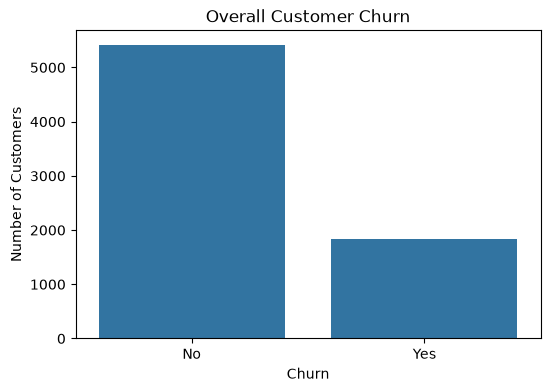

In [16]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Overall Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# Chart 2 — Churn Rate by Tenure Group ⭐

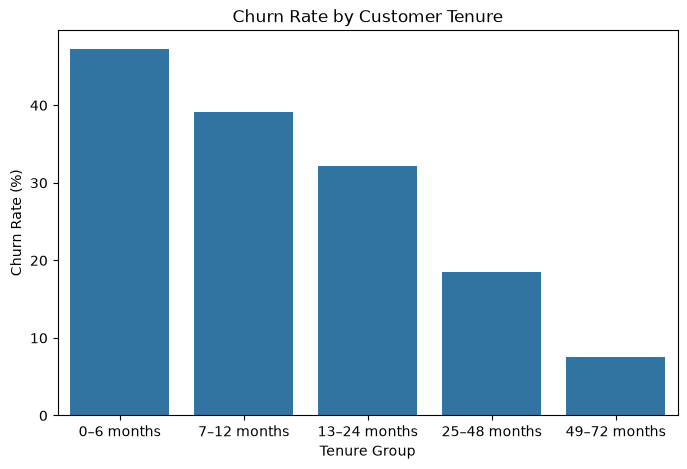

In [17]:
tenure_churn_rate = (
    df.groupby("TenureGroup", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=tenure_churn_rate.index,
    y=tenure_churn_rate.values
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.show()

# Chart 3 — Churn Rate by Contract

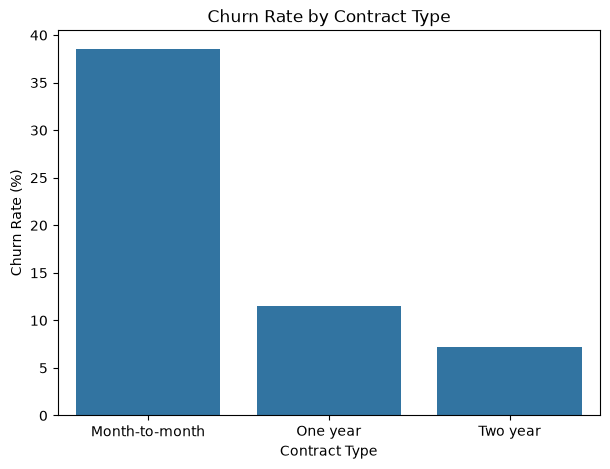

In [18]:
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(7, 5))
sns.barplot(
    x=contract_churn_rate.index,
    y=contract_churn_rate.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

# Chart 4 — Churn Rate by Internet Service

Does customer churn vary depending on the type of internet service they use?

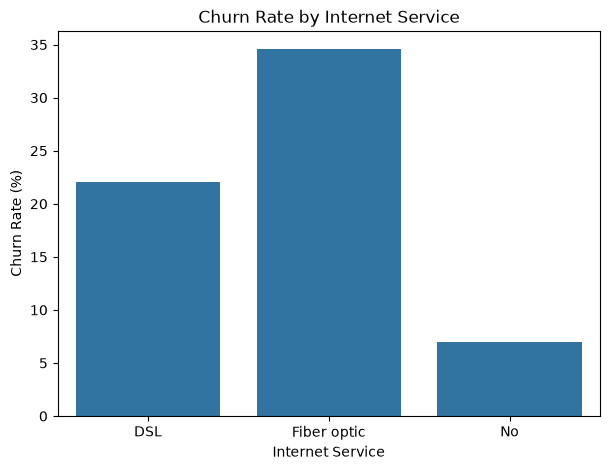

In [19]:
internet_churn_rate = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=internet_churn_rate.index,
    y=internet_churn_rate.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

`Fiber optic customers have the highest observed churn rate at about 34.55%.`

"I compared churn rates across internet service types and found that fiber-optic customers had the highest observed churn rate, around 34.6%, compared with 22.1% for DSL. This indicates that internet service type is associated with churn. I would investigate pricing, service quality, customer experience, and service configuration before concluding that fiber itself causes churn."

# Chart 5 — Churn Rate by Payment Method

Does churn vary depending on how customers pay?

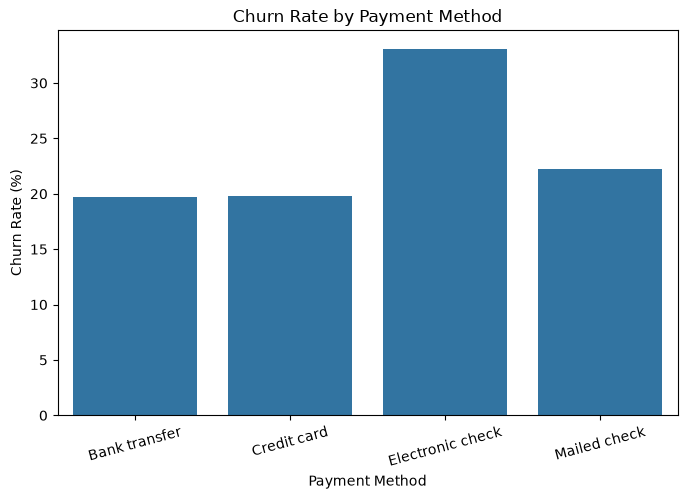

In [20]:
payment_churn_rate = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_churn_rate.index,
    y=payment_churn_rate.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.show()

`Electronic-check customers have the highest observed churn rate at approximately 33.1%.`

"I compared churn rates across payment methods and found that customers using electronic checks had the highest observed churn rate, around 33.1%. This makes electronic-check customers a segment worth investigating for retention. However, payment method itself should not be assumed to cause churn, so I would investigate whether this pattern is related to factors such as contract type, tenure, or customer characteristics."

# Chart 6 — High-Risk Segment Comparison

Which customer segments should the business pay the most attention to?

In [21]:
high_risk_segments = {
    "0–6 months + Fiber": 62.87,
    "0–6 months + Electronic check": 53.93,
    "High charges + M2M": 54.24,
    "0–6 months + M2M": 50.26,
    "0–6 months + M2M + Electronic check": 56.19
}

segment_churn = pd.Series(high_risk_segments)

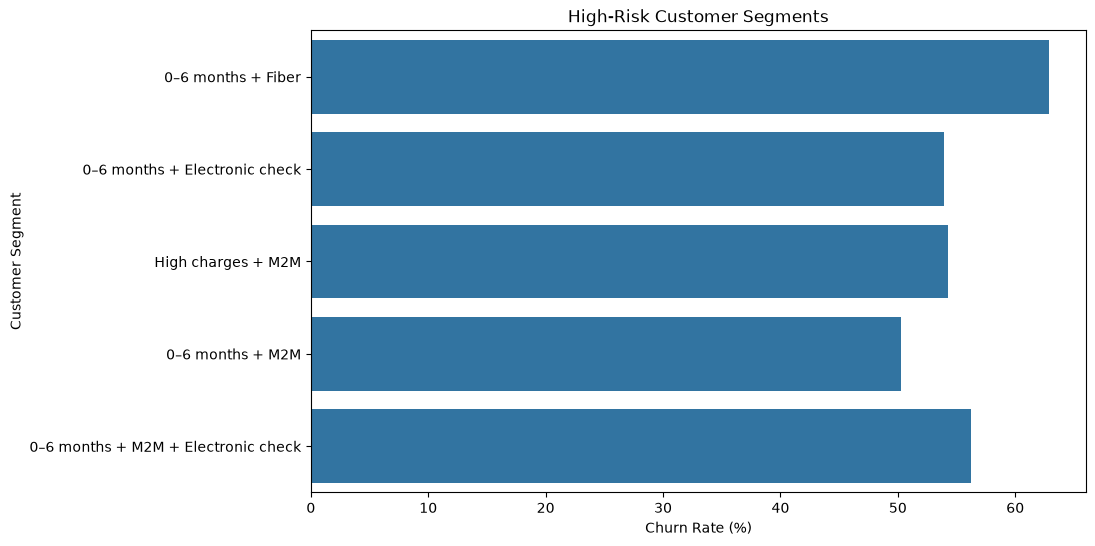

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_churn.values,
    y=segment_churn.index
)

plt.title("High-Risk Customer Segments")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Segment")
plt.show()

The highest-risk segment in this comparison is:

`0–6 months + Fiber → 62.87% churn`

Followed by:

`0–6 months + M2M + Electronic check → 56.19%`

New customers using fiber appear to be a particularly high-risk segment, so the company could investigate onboarding, early service experience, pricing, and support for this group.

## Step 7 — Final Business Insights

1. Strongest insight: Early-tenure customers

`Finding:`

0–6 months → 47.28% churn
49–72 months → 7.57% churn

`Business insight:`

Customers are substantially more likely to churn during the early stage of their relationship with the company.

`Business meaning:`
The first few months appear to be the most critical retention period.

2. Contract type

`Finding:`

Month-to-month → 38.56%
One-year → 11.46%
Two-year → 7.24%

`Business insight:`

Month-to-month customers have substantially higher observed churn than customers on longer-term contracts.

`Business meaning:`
Customers with lower contractual commitment represent an important retention segment.

3. Internet service

`Finding:`

Fiber optic → 34.55% churn

`Business insight:`

Fiber-optic customers show higher observed churn than DSL and customers without internet service.

`Business meaning:`
The company should investigate whether pricing, service experience, technical issues, or other characteristics of fiber customers are associated with the higher churn.

4. Payment method

`Finding:`

Electronic check → 33.10% churn

`Business insight:`

Customers using electronic checks have the highest observed churn among the payment methods.

`Business meaning:`
Electronic-check customers are another segment worth investigating for retention.

5. Monthly charges

`Finding:`

Low charges → 11.31%
High charges → 35.69%

`Business insight:`

Customers with higher monthly charges show substantially higher observed churn.

`Business meaning:`
Higher-paying customers may have greater price sensitivity or different service configurations, so pricing and perceived value should be investigated.

6. High-risk combination ⭐

`Our strongest segmentation finding:`
Customers with 0–6 months tenure, month-to-month contracts, and electronic-check payment had approximately 56.19% observed churn.

## Your final EDA conclusion

The analysis indicates that customer churn is strongly associated with customer lifecycle, contract type, internet service, payment method, and monthly charges. Early-tenure customers and month-to-month customers show particularly high churn, with certain combinations forming high-risk segments. These findings suggest that retention efforts should prioritize customers during the early lifecycle and focus on segments with multiple observed risk characteristics.

## Step 8 — Retention Recommendations

Based on our findings, what should the company do?

1. Focus on new customers ⭐

`Finding:`
0–6 month customers → 47.28% churn

`Recommendation:`

Strengthen the onboarding and early-customer engagement process during the first 6 months.

`Possible actions:`

Welcome/onboarding communication
Early service check-ins
Faster issue resolution
Usage guidance
Identify dissatisfied customers early

2. Target month-to-month customers

`Finding:`
Month-to-month → 38.56% churn

`Recommendation:`

Develop retention offers or incentives for high-risk month-to-month customers.

For example:

Longer-term plan incentives
Loyalty benefits
Contract upgrade offers

Don't assume everyone should be pushed into a long-term contract; test whether appropriate incentives improve retention.

3. Investigate high-risk fiber customers

`Finding:`
Fiber optic → 34.55% churn

`Recommendation:`

Investigate whether pricing, service quality, technical issues, or customer experience are contributing to higher churn among fiber customers.

This is an investigation recommendation, rather than claiming that fiber service causes churn.

4. Review high-charge customers

`Finding:`
High monthly charges → 35.69% churn

`Recommendation:`

Review pricing and perceived value for customers with high monthly charges, especially those also on month-to-month contracts.

`Possible areas to investigate:`

Pricing plans
Discounts
Service bundles
Competitor pricing
Customer satisfaction

5. Prioritize combined high-risk segments ⭐

`Finding:`

0–6 months + Month-to-month + Electronic check → 56.19% churn

`Recommendation:`

Create a targeted retention strategy for customers who have multiple observed risk characteristics rather than treating all customers equally.

This is probably the most business-oriented recommendation from our EDA.



| Finding                       | Recommended Action                          |
| ----------------------------- | ------------------------------------------- |
| High early-tenure churn       | Strengthen onboarding and early engagement  |
| High M2M churn                | Test retention/contract incentives          |
| High Fiber churn              | Investigate service, pricing and experience |
| High-charge churn             | Review pricing and perceived value          |
| Multiple-risk characteristics | Prioritize targeted retention campaigns     |


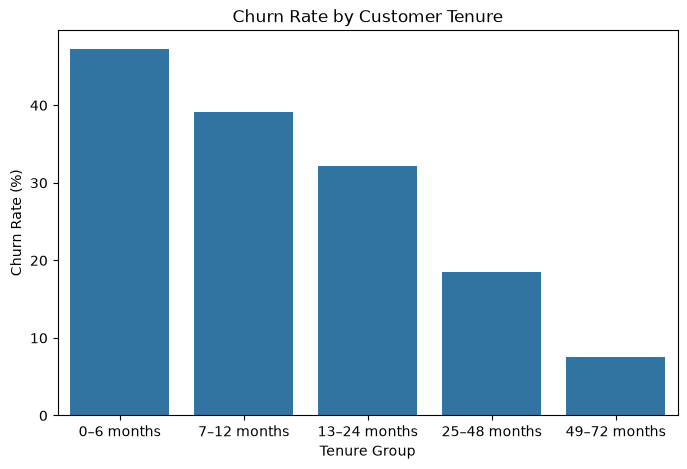

In [6]:
tenure_churn_rate = (
    df.groupby("TenureGroup", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=tenure_churn_rate.index,
    y=tenure_churn_rate.values
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.savefig("../outputs/charts/churn_rate_by_tenure.png",
            bbox_inches="tight")

plt.show()

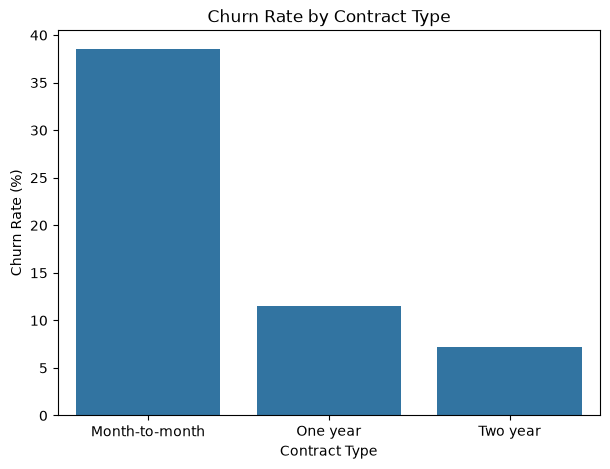

In [7]:
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=contract_churn_rate.index,
    y=contract_churn_rate.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.savefig("../outputs/charts/churn_rate_by_contract.png",
            bbox_inches="tight")

plt.show()

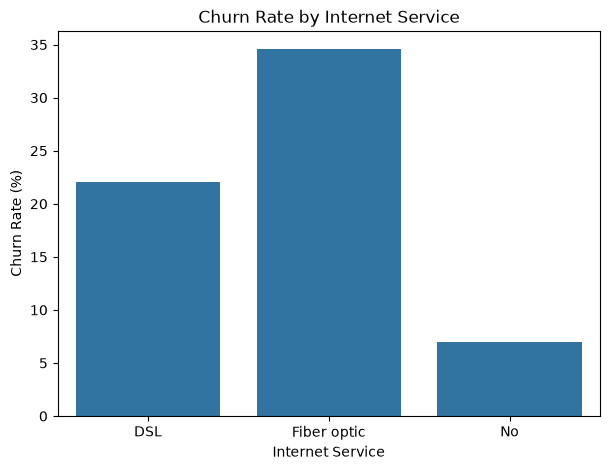

In [8]:
internet_churn_rate = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=internet_churn_rate.index,
    y=internet_churn_rate.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.savefig("../outputs/charts/churn_rate_by_internet_service.png",
            bbox_inches="tight")

plt.show()

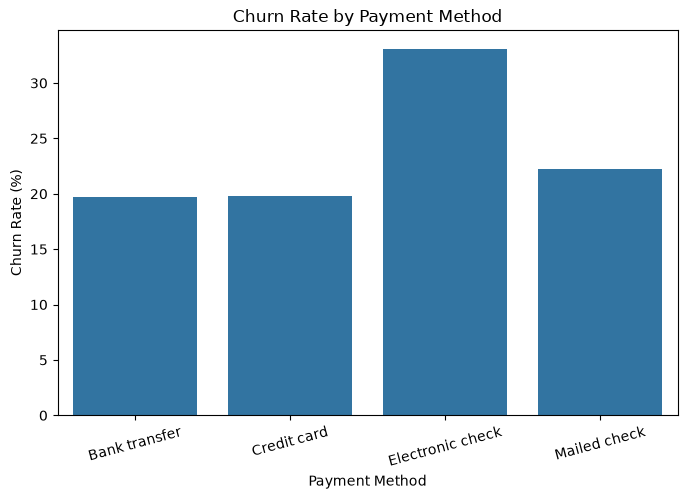

In [9]:
payment_churn_rate = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_churn_rate.index,
    y=payment_churn_rate.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)

plt.savefig("../outputs/charts/churn_rate_by_payment_method.png",
            bbox_inches="tight")

plt.show()

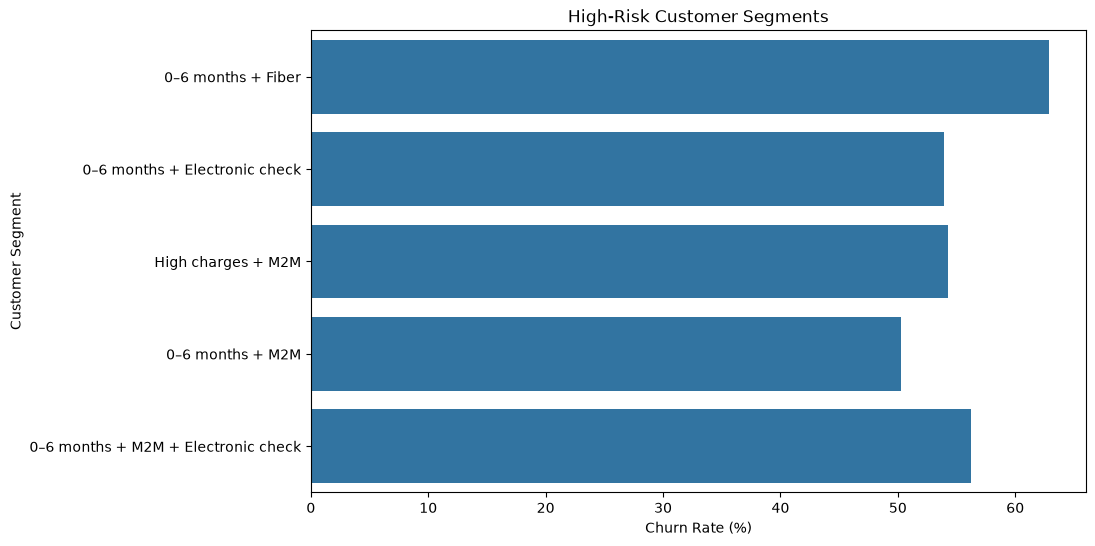

In [10]:
high_risk_segments = {
    "0–6 months + Fiber": 62.87,
    "0–6 months + Electronic check": 53.93,
    "High charges + M2M": 54.24,
    "0–6 months + M2M": 50.26,
    "0–6 months + M2M + Electronic check": 56.19
}

segment_churn = pd.Series(high_risk_segments)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_churn.values,
    y=segment_churn.index
)

plt.title("High-Risk Customer Segments")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Segment")

plt.savefig("../outputs/charts/high_risk_customer_segments.png",
            bbox_inches="tight")

plt.show()